# Continued EDA

## Table of Contents

## Set Up

In [238]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay

In [239]:
# show all dataframe columns
pd.set_option('display.max_columns', None)
# set matplotlib global settings eg. figsize
plt.rcParams['figure.figsize'] = (8.0, 6.0)

In [240]:
# Import hotel_clean_df
clean_df = pd.read_csv('clean_df')

#Import cxl_by_date
cxl_by_date = pd.read_csv('cxl_by_date')

#Import demand_by_date
demand_by_date = pd.read_csv('demand_by_date')

In [241]:
clean_df.head(5)
#cxl_by_date.head(5)
#demand_by_date.head(5)

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,122


In [242]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_week_number        119390 non-null  int64  
 4   stays_in_weekend_nights         119390 non-null  int64  
 5   stays_in_week_nights            119390 non-null  int64  
 6   adults                          119390 non-null  int64  
 7   children                        119390 non-null  int64  
 8   babies                          119390 non-null  int64  
 9   meal                            119390 non-null  int64  
 10  market_segment                  119390 non-null  object 
 11  distribution_channel            119390 non-null  object 
 12  is_repeated_gues

In [243]:
#Converting date columns back to datetime
clean_df['arrival_date'] = pd.to_datetime(clean_df['arrival_date'])
clean_df['reservation_status_date'] = pd.to_datetime(clean_df['reservation_status_date'])

# Additional EDA
- Total Cancellations
- Compare `market_segment` with `distribution_channel`. Are values the same? Can we drop one?
- Demand 
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Cancellations
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Booking Windows
    - Average `lead_time` of each reservation
    - `lead_time` by `customer_type`
    - `lead_time` by top 3 `market_segments`
- Cancellation Windows
    - How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?
    - Cancellation window by `customer_type`
    - Cancellation window by `market_segment`


In [244]:
# Total Cancellations
total_reservations = clean_df.shape[0]
total_cancelled = clean_df['is_canceled'].value_counts()[1]
total_cancel_pct = clean_df['is_canceled'].value_counts(normalize=True)[1]

print(f'Total Reservations: {total_reservations}')
print(f"Total Canceled Reservations: {total_cancelled}")
print(f"Percentage of Reservations Cancelled: {np.round(total_cancel_pct,4)*100}%")

Total Reservations: 119390
Total Canceled Reservations: 44224
Percentage of Reservations Cancelled: 37.04%


The cancellation percentage may initially feel high, however given my experience in the industry, it's not abnormal to see cancellation percentages this high because this value also includes date changes, no shows, and cancellations.

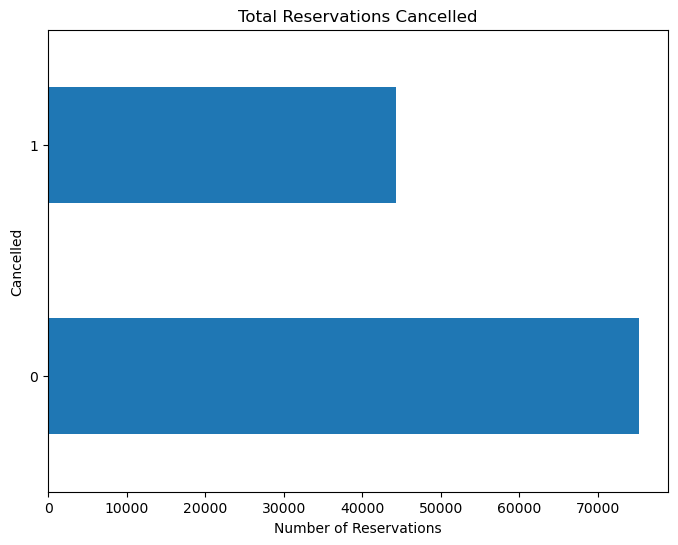

In [245]:
# Total Cancellations
clean_df['is_canceled'].value_counts().plot(kind='barh')

plt.title('Total Reservations Cancelled')
plt.ylabel('Cancelled')
plt.xlabel('Number of Reservations')
plt.show()


In [246]:
# Compare market_segment and distribution_channel
print(clean_df[['market_segment','distribution_channel']].value_counts(),'\n\n')
print(clean_df['market_segment'].value_counts(),'\n\n')
print(clean_df['distribution_channel'].value_counts())

market_segment  distribution_channel
Online TA       TA/TO                   56153
Offline TA/TO   TA/TO                   23946
Groups          TA/TO                   17111
Direct          Direct                  12276
Corporate       Corporate                4788
Groups          Direct                   1472
                Corporate                1228
Complementary   Direct                    576
Corporate       TA/TO                     335
Direct          TA/TO                     237
Aviation        Corporate                 227
Offline TA/TO   Corporate                 212
Corporate       Direct                    172
Online TA       GDS                       147
                Direct                    133
Direct          Corporate                  90
Complementary   Corporate                  89
                TA/TO                      78
Offline TA/TO   GDS                        45
Online TA       Corporate                  43
Offline TA/TO   Direct                     

The values "somewhat" overlap, however the market segment is the segmentation of the the guest type.  Whereas the distribution channel is the form in which the reservation was made.  These are indeed different and I will keep them separate.

## Additional Demand EDA:
- by Customer Type 
- by Demand by Market Segment

In [247]:
# Demand by customer_type
clean_df['customer_type'].value_counts(normalize=True) *100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

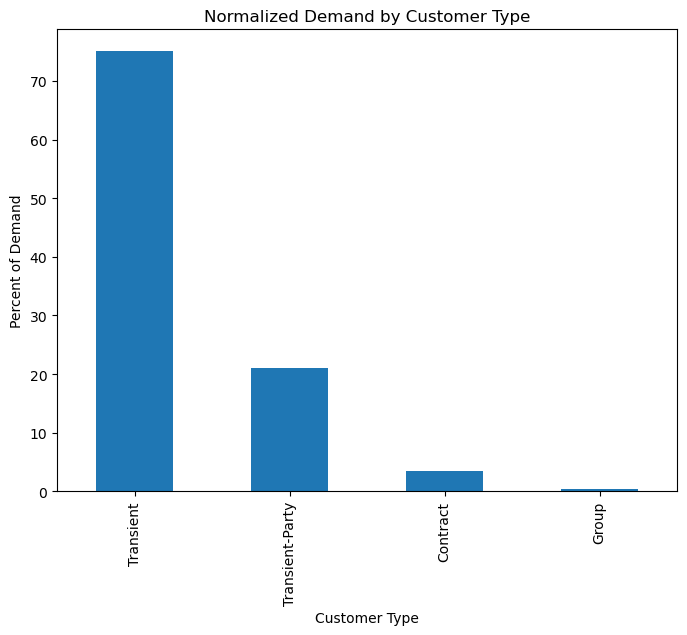

In [248]:
# Demand by customer_type
(clean_df['customer_type'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Percent of Demand')
plt.show()


Looking at customer types, I want to combine the two Transient customer_types as well as removing reservations under the Group customer type since there is very few group reservations in this dataset.  Also, in my experience and understanding of Group demand, they are very different to transient demand and therefore I will focus primarily on transient demand only.

I will make these changes in the upcoming feature engineering section.

***


In [249]:
# Demand by market_segment
clean_df['market_segment'].value_counts(normalize=True) *100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

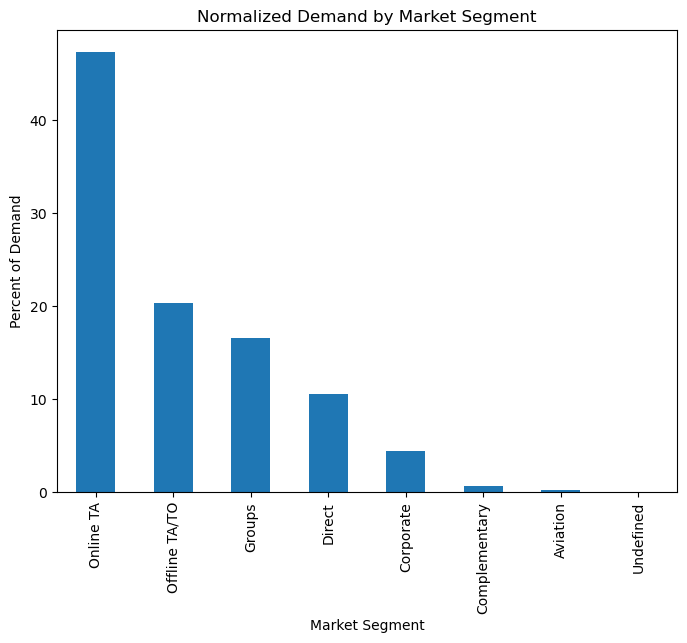

In [250]:
# Demand by market_segment
(clean_df['market_segment'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Percent of Demand')
plt.show()


## Additional Cancellations EDA
- by Market Segment 
- by Customer Type 

In [252]:
# Creating a DF with market segments by cancellations
segmentation_cxl_df = clean_df.groupby(['market_segment', 'is_canceled']).size().unstack(fill_value=0)
segmentation_cxl_df

is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7714,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Undefined,0,2


In [253]:
# Adding a cancellation percent to the dataframe
segmentation_cxl_df['cxl_percent'] = np.round(segmentation_cxl_df[1] / (segmentation_cxl_df[1] + segmentation_cxl_df[0])*100, 4)

In [254]:
# Sanity check
segmentation_cxl_df

is_canceled,0,1,cxl_percent
market_segment,,,
Aviation,185,52,21.9409
Complementary,646,97,13.0552
Corporate,4303,992,18.7347
Direct,10672,1934,15.3419
Groups,7714,12097,61.0620
Offline TA/TO,15908,8311,34.3160
Online TA,35738,20739,36.7211
Undefined,0,2,100.0000


## Question 1a : Unable to add the labels in the stacked bar plot for cancellation percentage

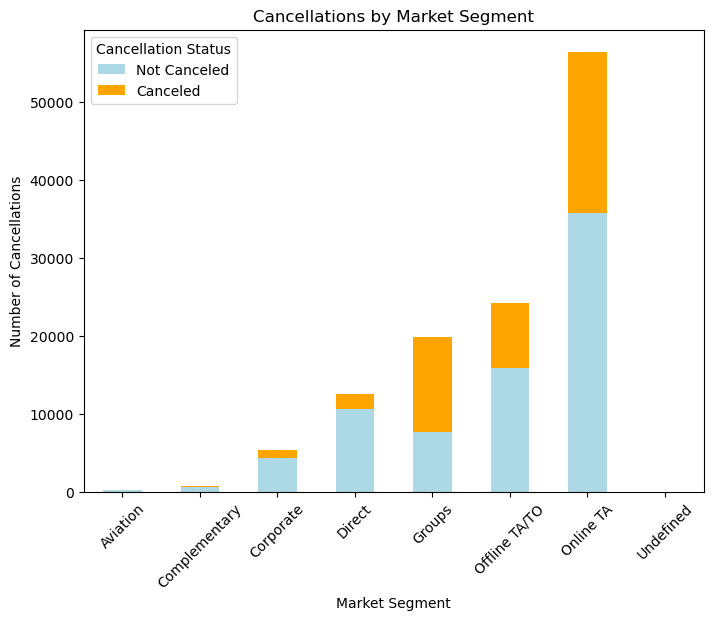

In [255]:
# Stacked Bar Plot for Cancellations by Market Segment
clean_df.groupby(['market_segment', 'is_canceled']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

#for index, seg in segmentation_cxl_df.iterrows():
#    plt.text(index, seg[0], f"{seg['cxl_percent']:.1f}%", ha='center', va='center', color='black', fontsize=10)

plt.title('Cancellations by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

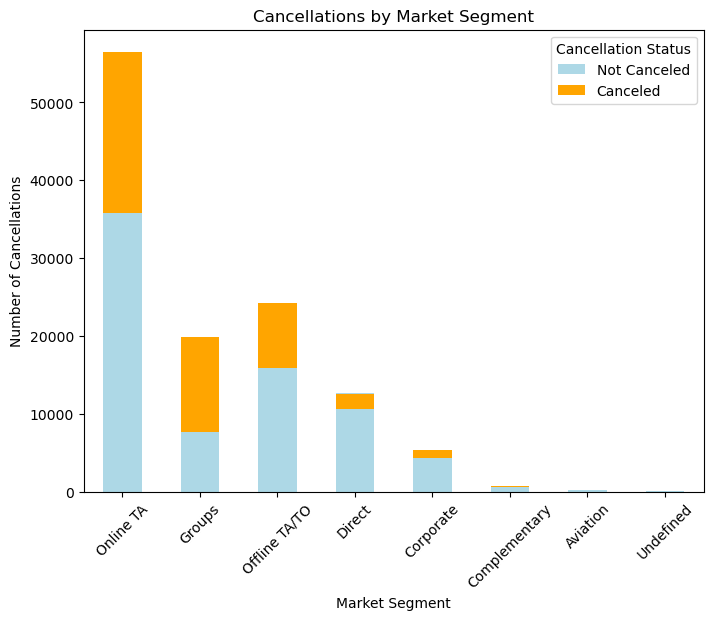

In [256]:
# Cancellations by Market Segment Plot
segmentation_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

In [257]:
# Cancellations by Customer Type
#clean_df[['is_canceled','customer_type']].value_counts()
clean_df.groupby('customer_type')['is_canceled'].value_counts()

customer_type    is_canceled
Contract         0               2814
                 1               1262
Group            0                518
                 1                 59
Transient        0              53099
                 1              36514
Transient-Party  0              18735
                 1               6389
Name: count, dtype: int64

In [258]:
# Creating a DF with customer type by cancellations
customer_cxl_df = clean_df.groupby(['customer_type', 'is_canceled']).size().unstack(fill_value=0)
customer_cxl_df

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


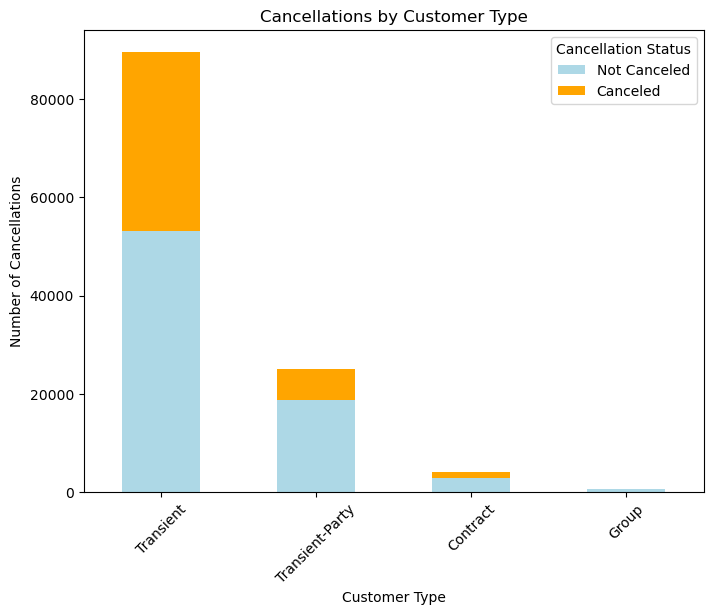

In [259]:
# Cancellations by Customer Type Plot
customer_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

## Question 5: Is it necessary to transform the market segment and customer type features so that I can see a breakdown by date with the date as the index?

## Booking Window EDA
- `lead_time` by `customer_type`

In [260]:
clean_df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

The average lead time for bookings are 104 days with the max being 737. That is booking a hotel over 2 years in advanced.

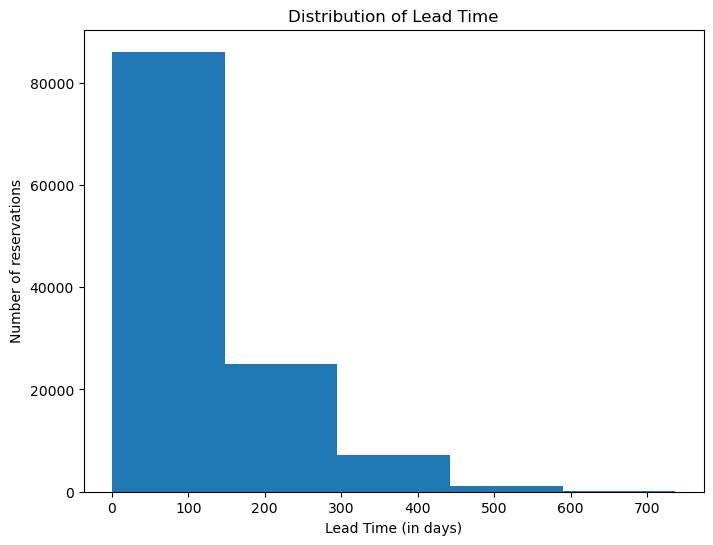

In [261]:
# Plot the distribution of the lead times
clean_df['lead_time'].plot(kind='hist', bins=5)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (in days)')
plt.ylabel('Number of reservations')
plt.show()


In [262]:
# Create lead time ranges 
lead_time_range = [
(None, 7, 'less than 7'),
(7, 14, 'between 7-14'),
(14, 30, 'between 14-30'),
(30, None, 'more than 30')    
]

In [263]:
for lower, upper, label in lead_time_range:
    if lower is None:
        count = clean_df[clean_df['lead_time'] < upper].shape[0]
    elif upper is None:
        count = clean_df[clean_df['lead_time'] >= lower].shape[0]
    else:
        count = clean_df[(clean_df['lead_time'] >= lower) & (clean_df['lead_time'] < upper)].shape[0]
    
    print(f"Number of reservations that booked {label} days in advance: {count}")

Number of reservations that booked less than 7 days in advance: 18415
Number of reservations that booked between 7-14 days in advance: 7392
Number of reservations that booked between 14-30 days in advance: 12240
Number of reservations that booked more than 30 days in advance: 81343


In [264]:
# # Identify the lead time ranges
# print(f"Number of reservations that booked less than 30 days in advanced: {clean_df[clean_df['lead_time']<=30].shape[0]}")
# print(f"Number of reservations that booked between 30-60 days in advanced: {clean_df[(clean_df['lead_time']>=30) & (clean_df['lead_time']<60)].shape[0]}")
# print(f"Number of reservations that booked between 60-90 days in advanced: {clean_df[(clean_df['lead_time']>=60) & (clean_df['lead_time']<90)].shape[0]}")
# print(f"Number of reservations that booked between 90-180 days in advanced: {clean_df[(clean_df['lead_time']>=90) & (clean_df['lead_time']<180)].shape[0]}")
# print(f"Number of reservations that booked between 180-365 days in advanced: {clean_df[(clean_df['lead_time']>=180) & (clean_df['lead_time']<365)].shape[0]}")
# print(f"Number of reservations that booked over 365+ days in advanced: {clean_df[clean_df['lead_time']>=365].shape[0]}")


In [265]:
# # Identify the lead time ranges
# print(f"Number of reservations that booked less than 7 days in advanced: {clean_df[clean_df['lead_time']<7].shape[0]}")
# print(f"Number of reservations that booked between 7-14 days in advanced: {clean_df[(clean_df['lead_time']>=7) & (clean_df['lead_time']<14)].shape[0]}")
# print(f"Number of reservations that booked between 14-30 days in advanced: {clean_df[(clean_df['lead_time']>=14) & (clean_df['lead_time']<30)].shape[0]}")
# print(f"Number of reservations that booked over 30+ days in advanced: {clean_df[clean_df['lead_time']>=30].shape[0]}")


In order to view the lead time by customer type and market segment, feature engineering will need to be completed to group the lead times into smaller buckets.

# Feature Engineering
1. Calculate Cancellation days before arrival
2. Group Customer_Type Transient and Transient Party together
3. Isolate only Transient customer_type
4. Calculate and group Length of Stay into buckets
5. One Hot Encoding for remaining categorical features

## Cancellation Days before arrival Feature engineering
- How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?

Additional EDA: 
- Cancellation window by `market_segment`


In [266]:
# Value counts of reservation status
clean_df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [267]:
# Calculate the difference between the arrival_date and reservation_status_date  
clean_df['date_diff'] = (clean_df['arrival_date'] - clean_df['reservation_status_date']).dt.days # converting the results into an integer

In [268]:
# Sanity check
clean_df['date_diff'].head(5)

0    0
1    0
2   -1
3   -1
4   -2
Name: date_diff, dtype: int64

In [269]:
# pull data where reservation_status == Canceled
canceled_res = clean_df[clean_df['reservation_status']=='Canceled']

In [270]:
canceled_res['date_diff'].describe()

count    43017.000000
mean        88.287747
std         90.795044
min          0.000000
25%         19.000000
50%         56.000000
75%        130.000000
max        526.000000
Name: date_diff, dtype: float64

The average date difference between a cancellation being made and the arrival date of the reservation is 88 days. 

In [271]:
# Value counts of date_diff to see the top 10 date differences with cancelled reservations
canceled_res['date_diff'].value_counts().head(10)

date_diff
0     881
3     718
6     636
1     630
5     603
7     599
11    593
4     581
16    531
10    508
Name: count, dtype: int64

The largest number of cancellations occur on the same day of arrival (881 cancellations)

In [272]:
# Date diff by market segment
canceled_res.groupby(['market_segment', 'date_diff']).size().unstack(fill_value=0)


date_diff,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,332,333,334,335,336,337,338,339,342,343,344,345,346,347,348,349,351,352,353,355,357,358,361,365,366,367,369,370,372,373,375,379,384,386,387,393,400,401,403,405,406,407,411,414,421,428,435,442,449,456,463,470,477,484,491,498,505,512,519,526
market_segment,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Aviation,10,9,6,6,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Complementary,38,14,4,6,2,3,0,2,2,4,0,4,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Corporate,120,61,37,31,29,56,24,36,10,6,5,13,11,6,4,7,6,12,4,3,8,5,2,9,4,6,7,7,11,1,2,4,13,12,0,1,0,1,100,1,2,2,2,0,7,3,0,1,2,5,39,1,1,4,2,1,5,1,1,69,1,0,0,1,1,0,0,0,0,35,8,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

Many of the cancellations that are further out (400+ days) are groups. While majority of the cancellations within 10 days are with Online Travel Agents.

## Customer Type Feature Engineering
- Group Customer_Type Transient and Transient Party together
- Isolate only Transient customer_type

In [273]:
# Checking customer_type values
clean_df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [274]:
# Change all Transient-Party to be Transient
clean_df['customer_type'].replace('Transient-Party', 'Transient',inplace=True)

In [275]:
# Sanity Check
clean_df['customer_type'].value_counts()

customer_type
Transient    114737
Contract       4076
Group           577
Name: count, dtype: int64

In [276]:
clean_df.shape

(119390, 29)

In [277]:
# Drop all rows containing Contract or Group customer_type
clean_df = clean_df[clean_df['customer_type'] == 'Transient'].reset_index(drop=True)
clean_df

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand,date_diff
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122,0
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122,0
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122,-1
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122,-1
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01,122,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,City Hotel,0,23,35,2,5,2,0,0,1,Offline TA/TO,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,96.14,0,0,Check-Out,2017-09-06,2017-08-30,89,-7
114733,City Hotel,0,102,35,2,5,3,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,225.43,0,2,Check-Out,2017-09-07,2017-08-31,134,-7
114734,City Hotel,0,34,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,157.71,0,4,Check-Out,2017-09-07,2017-08-31,134,-7
114735,City Hotel,0,109,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,104.40,0,0,Check-Out,2017-09-07,2017-08-31,134,-7


## Length of Stay Feature Engineering 
- Calculate and group Length of Stay into buckets

In [278]:
clean_df[['stays_in_week_nights', 'stays_in_weekend_nights']]

,stays_in_week_nights,stays_in_weekend_nights
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0
...,...,...
114732,5,2
114733,5,2
114734,5,2
114735,5,2


In [279]:
# Add stays_in_weekend_nights + stays_in_week_nights
clean_df['los'] = clean_df['stays_in_week_nights'] + clean_df['stays_in_weekend_nights']

In [280]:
# Sanity check
clean_df['los'].value_counts().head(10)

los
2     26499
3     26457
1     20535
4     16960
7      7782
5      7574
6      3742
8      1119
10      920
9       782
Name: count, dtype: int64

Looking at the value counts for length of stay, over 90,000 of the 114,000 reservations stay between 1-4 nights.

## One Hot Encoding Feature Engineering:
- hotel
- market_segment
- distribution_channel
- deposit_type
- customer_type
- reservation_status


In [281]:
# Instantiate OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

In [282]:
# Fit and transform categorical features in OHE
encoded_array = one_hot_encoder.fit_transform(clean_df[['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type','reservation_status']])
encoded_array

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [283]:
one_hot_encoder.categories_

[array(['City Hotel', 'Resort Hotel'], dtype=object),
 array(['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups',
        'Offline TA/TO', 'Online TA', 'Undefined'], dtype=object),
 array(['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined'], dtype=object),
 array(['No Deposit', 'Non Refund', 'Refundable'], dtype=object),
 array(['Transient'], dtype=object),
 array(['Canceled', 'Check-Out', 'No-Show'], dtype=object)]

In [284]:
# Put into a dataframe to get column names
encoded_df = pd.DataFrame(encoded_array, columns=one_hot_encoder.get_feature_names_out(['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type','reservation_status']), dtype=int)

In [285]:
encoded_df.tail()

,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,reservation_status_Canceled,reservation_status_Check-Out,reservation_status_No-Show
114732,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
114733,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
114734,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
114735,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
114736,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0


In [286]:
final_df = pd.concat([clean_df,encoded_df],axis=1)

In [287]:
# Drop original columns that were used for One Hot Encoding
final_df.drop(columns='hotel',inplace=True)
final_df.drop(columns='market_segment',inplace=True)
final_df.drop(columns='distribution_channel',inplace=True)
final_df.drop(columns='deposit_type',inplace=True)
final_df.drop(columns='customer_type',inplace=True)
final_df.drop(columns='reservation_status',inplace=True)

In [288]:
# Final dataframe ready for modeling
final_df

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,date_diff,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,reservation_status_Canceled,reservation_status_Check-Out,reservation_status_No-Show
0,0,342,27,0,0,2,0,0,1,0,0,0,3,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0
1,0,737,27,0,0,2,0,0,1,0,0,0,4,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0
2,0,7,27,0,1,1,0,0,1,0,0,0,0,0,0,0,75.00,0,0,2015-07-02,2015-07-01,122,-1,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0
3,0,13,27,0,1,1,0,0,1,0,0,0,0,1,0,0,75.00,0,0,2015-07-02,2015-07-01,122,-1,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0,14,27,0,2,2,0,0,1,0,0,0,0,1,0,0,98.00,0,1,2015-07-03,2015-07-01,122,-2,2,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,0,23,35,2,5,2,0,0,1,0,0,0,0,1,0,0,96.14,0,0,2017-09-06,2017-08-30,89,-7,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1,0
114733,0,102,35,2,5,3,0,0,1,0,0,0,0,1,0,0,225.43,0,2,2017-09-07,2017-08-31,134,-7,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
114734,0,34,35,2,5,2,0,0,1,0,0,0,0,1,0,0,157.71,0,4,2017-09-07,2017-08-31,134,-7,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
114735,0,109,35,2,5,2,0,0,1,0,0,0,0,1,0,0,104.40,0,0,2017-09-07,2017-08-31,134,-7,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0


# Model Preparation

1. Train Test Split
2. Scaling

## Train/Test Split

In [289]:
# Separating X and y target variable (is_canceled)
X = final_df.drop('is_canceled', axis=1)
y = final_df['is_canceled']

In [305]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [306]:
X_train

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,date_diff,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,reservation_status_Canceled,reservation_status_Check-Out,reservation_status_No-Show
59831,54,3,0,3,2,0,0,1,0,0,0,0,1,0,0,65.0,0,0,2016-11-25,2017-01-18,219,54,3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0
1837,0,39,0,1,2,0,0,1,0,0,0,0,0,0,0,89.0,0,0,2015-09-26,2015-09-25,275,-1,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0
109531,49,24,0,4,2,0,0,1,0,0,0,0,1,0,0,121.6,0,1,2017-06-18,2017-06-14,159,-4,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
48253,91,20,1,2,2,0,0,1,0,0,0,0,1,0,0,140.4,0,0,2016-02-22,2016-05-13,237,81,3,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0
69787,285,31,0,5,2,0,0,1,0,0,0,0,1,0,0,107.1,0,1,2016-12-28,2017-08-01,178,216,5,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59537,552,2,0,2,2,0,0,1,0,0,0,0,1,0,0,62.0,0,0,2015-10-21,2017-01-12,138,449,2,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1,1,0,0
85393,1,22,0,2,2,0,0,1,0,0,0,0,1,0,0,176.0,0,1,2016-05-28,2016-05-26,276,-2,2,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0
80064,16,9,0,1,1,0,0,1,0,0,0,1,0,1,0,31.0,0,1,2016-02-27,2016-02-26,245,-1,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0
899,0,32,0,1,2,0,0,1,0,0,0,0,1,0,0,171.9,1,0,2015-08-09,2015-08-08,206,-1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0


## Extract features from datetime columns from X_train and X_test
- arrival_date
- reservation_status_date

Before we can scale, arrival_date and reservation_status_date needs to be transformed since a logistic regression model cannot take datetime

In [318]:
X_train.head(2)

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,day_demand,date_diff,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,reservation_status_Canceled,reservation_status_Check-Out,reservation_status_No-Show,arrival_year,arrival_month,arrival_dow,arrival_day,status_year,status_month,status_dow,status_day
59831,54,3,0,3,2,0,0,1,0,0,0,0,1,0,0,65.0,0,0,219,54,3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0,2017,1,2,18,2016,11,4,25
1837,0,39,0,1,2,0,0,1,0,0,0,0,0,0,0,89.0,0,0,275,-1,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,2015,9,4,25,2015,9,5,26


In [308]:
# Extract year, month, day of month from arrival_date for X_train
X_train['arrival_year'] = X_train['arrival_date'].dt.year
X_train['arrival_month'] = X_train['arrival_date'].dt.month
X_train['arrival_dow'] = X_train['arrival_date'].dt.weekday
X_train['arrival_day'] = X_train['arrival_date'].dt.day

# Extract year, month, day of month from arrival_date for X_test
X_test['arrival_year'] = X_test['arrival_date'].dt.year
X_test['arrival_month'] = X_test['arrival_date'].dt.month
X_test['arrival_dow'] = X_test['arrival_date'].dt.weekday
X_test['arrival_day'] = X_test['arrival_date'].dt.day


In [309]:
# Extract year, month, day of month from reservation_status_date for X_train
X_train['status_year'] = X_train['reservation_status_date'].dt.year
X_train['status_month'] = X_train['reservation_status_date'].dt.month
X_train['status_dow'] = X_train['reservation_status_date'].dt.weekday
X_train['status_day'] = X_train['reservation_status_date'].dt.day

# Extract year, month, day of month from reservation_status_date for X_test
X_test['status_year'] = X_test['reservation_status_date'].dt.year
X_test['status_month'] = X_test['reservation_status_date'].dt.month
X_test['status_dow'] = X_test['reservation_status_date'].dt.weekday
X_test['status_day'] = X_test['reservation_status_date'].dt.day


In [310]:
# Drop original datetime columns for X_train
X_train.drop(columns='reservation_status_date', inplace=True)
X_train.drop(columns='arrival_date',inplace=True)

# Drop original datetime columns for X_test
X_test.drop(columns='reservation_status_date', inplace=True)
X_test.drop(columns='arrival_date',inplace=True)

In [317]:
# Sanity check before scaling
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91789 entries, 59831 to 111010
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   lead_time                       91789 non-null  int64  
 1   arrival_date_week_number        91789 non-null  int64  
 2   stays_in_weekend_nights         91789 non-null  int64  
 3   stays_in_week_nights            91789 non-null  int64  
 4   adults                          91789 non-null  int64  
 5   children                        91789 non-null  int64  
 6   babies                          91789 non-null  int64  
 7   meal                            91789 non-null  int64  
 8   is_repeated_guest               91789 non-null  int64  
 9   previous_cancellations          91789 non-null  int64  
 10  previous_bookings_not_canceled  91789 non-null  int64  
 11  booking_changes                 91789 non-null  int64  
 12  agent                           

## Scaling

In [312]:
# Scaling
scaler = StandardScaler()

# Fit and transform train
X_train_scaled = scaler.fit_transform(X_train)

# Only transforming the test
X_test_scaled = scaler.transform(X_test)


# Baseline Logistic Regression

In [ ]:
# Instantiate the model
log_reg = LogisticRegression()

# Fit the model
log_reg.fit(X_train_scaled, y_train)

# Score the basemodel
print(f' Train score: {log_reg.score(X_train_scaled, y_train)}')

# Score on the test data
print(f' Test score: {log_reg.score(X_test_scaled, y_test)}')


 Train score: 1.0
 Test score: 1.0


## Question 1: Both Train and Test Scores are 100%. This does not look right...
- I did Train/Test split first, then extracted the day/month/year from my datetime variables (since those couldnt be scaled), scaled the data, and fit the model's on X_train_scaled.  When I ran the model on the unscaled data, it looked less "perfect"...

In [380]:
# Running the model on the unscaled data to see any differences

# Instantiate the model
log_reg = LogisticRegression(max_iter=1000)

# Fit the model
log_reg.fit(X_train, y_train)

# Score the basemodel
print(f' Train score: {log_reg.score(X_train, y_train)}')

# Score on the test data
print(f' Test score: {log_reg.score(X_test, y_test)}')


 Train score: 1.0
 Test score: 0.9999564232177096


/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


| Model             | Train Score | Test Score |
|-------------------|-------------|------------|
| Baseline LogReg   | 100%        | 100%       |

## K-Fold Cross-Validation

In [324]:
# Instantiate the model
log_reg2 = LogisticRegression()

# Perform 5-fold cross-validation
scores = cross_val_score(log_reg2, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {scores}")

Cross-validation scores: [1. 1. 1. 1. 1.]


## Hyperparameter optimization for C

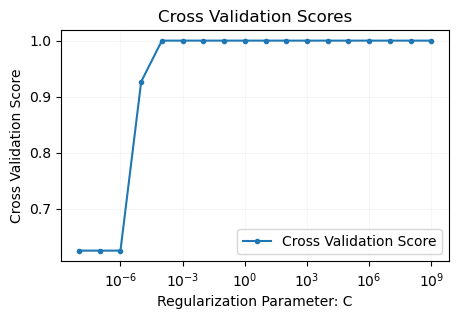

The best model has C =  0.001


In [ ]:
#Use Cross Validation to find the best C value

# Store the results
cross_validation_scores = []

# Create an array of powers of ten for the values of inverse regularization strength C
C_range = 10 ** np.array(range(-8, 10), dtype=float)

# Perform cross validation
for C in C_range:
    model = LogisticRegression(C=C, random_state=1)

    # The cross validation score (mean of scores from all folds)
    cv_score = np.mean(cross_val_score(model, X_train_scaled, y_train, cv=5))

    # Append the score
    cross_validation_scores.append(cv_score)

plt.figure(figsize=(5,3))
plt.plot(C_range, cross_validation_scores, label="Cross Validation Score", marker=".")
plt.xscale("log")
plt.grid(alpha=0.1)
plt.xlabel("Regularization Parameter: C")
plt.ylabel("Cross Validation Score")
plt.title("Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal C
index_of_max = np.array(cross_validation_scores).argmax()
print("The best model has C = ", C_range[index_of_max])

## Question 2: So my CV to identify the best C value resulted in 0.001 but it still gave me accuracy of 100%.  As decreased the C value it gave me percentages that were more what I'm used to seeing. Should i try to get an accuracy closer to 90-95% vs. the 99-100%?

## Cross Validation with optimized C Hyperparameter

In [356]:
# Instantiate the model
log_reg2 = LogisticRegression(C=0.001)

# Perform 5-fold cross-validation
scores = cross_val_score(log_reg2, X_train_scaled, y_train, cv=5)
print(f"Average Cross-validation scores: {np.mean(scores)}")


Average Cross-validation scores: 1.0


In [357]:
# Instantiate the model
log_reg2 = LogisticRegression(C=0.001)

# Fit the model
log_reg2.fit(X_train_scaled, y_train)

# Score the basemodel
print(f' Train score: {log_reg2.score(X_train_scaled, y_train)}')

# Score on the test data
print(f' Test score: {log_reg2.score(X_test_scaled, y_test)}')

 Train score: 1.0
 Test score: 1.0


## PCA with Logreg model
- Attempting PCA with the baseline model to see if model scores change

In [363]:
# Create the PCA object
PCA_object = PCA(n_components=10)

# Fit the PCA object to the data
PCA_object.fit(X_train_scaled)

# Transform the original data
X_PCA_train = PCA_object.transform(X_train_scaled)
X_PCA_test = PCA_object.transform(X_test_scaled)

## Question 3: When I'm building on top of the original baseline LogReg model, should I instantiate a new log_reg model or can i reuse a previous one?

In [364]:
# Instantiate
log_reg3 = LogisticRegression(C=0.001)

# Fit logreg model to X_train
log_reg3.fit(X_PCA_train, y_train)

# Scoring the logreg model
print(f' Train score: {log_reg3.score(X_PCA_train, y_train)}')
print(f' Test score: {log_reg3.score(X_PCA_test, y_test)}')

 Train score: 0.9910555731078887
 Test score: 0.9903259543315321


After applying PCA, the accuracies between train and test have dropped to ~99%

| Model    | Train Score | Test Score | Hyperparameter C | K-Fold Cross | PCA n_components |
|----------|-------------|------------|------------------|--------------|------------------|
| Log_Reg  | 100%        | 100%       |                  |              |                  |
| Log_Reg2 | 100%        | 100%       | C = 0.001        |       5      |                  |
| Log_Reg3 | 99.11%      | 99.03%     | C = 0.001        |              |        10        |



## Confusion Matrix
Before any additional hyperparameter tuning, I want to evaluate other metrics of the model such as Recall, Precision, and F1 scores.

Using the baseline log_reg for confusion matrix

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


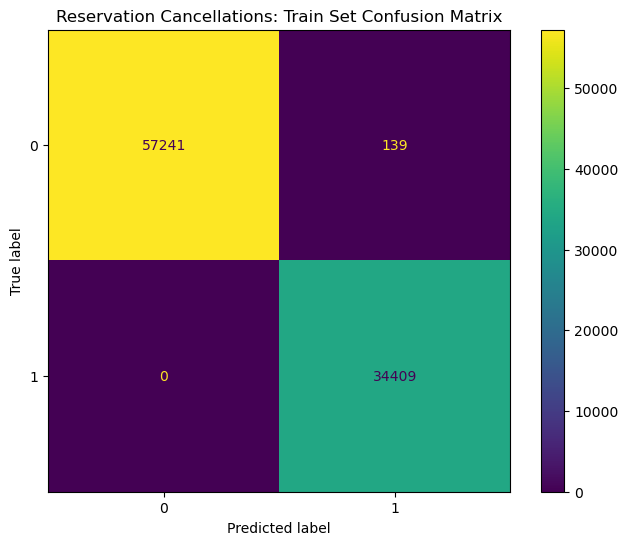

In [374]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_train_scaled, y_train)

plt.title('Reservation Cancellations: Train Set Confusion Matrix')

plt.show()

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


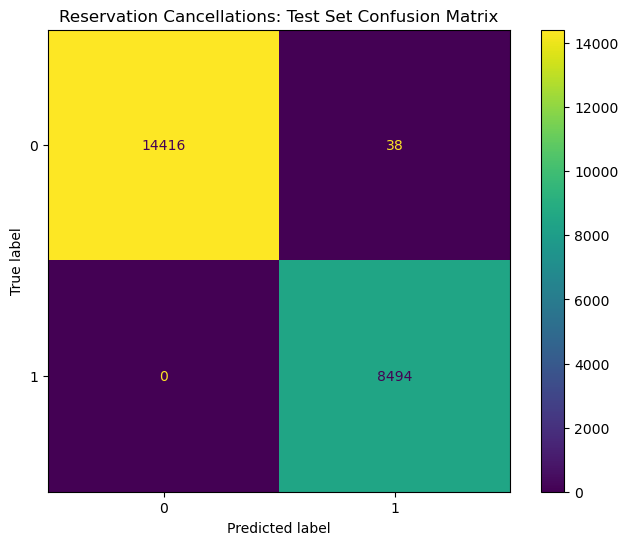

In [375]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test)

plt.title('Reservation Cancellations: Test Set Confusion Matrix')
#plt.xlabel('True Cancelled')
#plt.ylabel('Predicted Cancelled')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: All of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: Very few of the reservations that were predicted to cancel, actually did not cancel
- **False Negatives**: None of the reservations that cancelled were missed by our model and classified that they would not cancel
- **True Positives**: All of the cancelled reservations were correctly identified by the model.

In [377]:
# Get class predictions
y_pred = log_reg.predict(X_test_scaled)

/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [379]:
initial_report = classification_report(y_test, y_pred)
print(initial_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14454
           1       1.00      1.00      1.00      8494

    accuracy                           1.00     22948
   macro avg       1.00      1.00      1.00     22948
weighted avg       1.00      1.00      1.00     22948



## Question 4: After running my confusion matrix and classification reports, I think something is wrong and I may have data leakage somewhere or maybe I have too many features still even after running PCA?